# 👤 Face Detection using Haar Cascade
**Recognition Tasks | Classical Computer Vision**

---

## 💡 What is Haar Cascade?

Viola-Jones (2001) — the first **real-time face detector** on CPU, running at 15 FPS on 2001 hardware. No deep learning — just clever engineering.

**How it works (simple explanation):**
1. Uses thousands of simple **Haar-like features** — black & white rectangles that ask questions like *"is the eye region darker than the forehead?"*
2. Trains a **cascade of weak classifiers** (AdaBoost) — early stages quickly reject non-faces
3. Runs on a **sliding window + image pyramid** → checks multiple scales

> 💬 OpenCV ships pre-trained Haar cascade XML files — we just load and use them. No training needed!

---

## 🧮 Key Parameters of detectMultiScale()

| Parameter | What it controls |
|---|---|
| `scaleFactor` | How much image is reduced per scale (1.1 = 10% smaller each step) |
| `minNeighbors` | Min detections needed to keep a box (higher = fewer false positives) |
| `minSize` | Minimum face size in pixels to detect |

---

## ⚠️ Limitations
- ❌ Fails on **side-facing or tilted** faces
- ❌ Sensitive to **lighting and occlusion**
- ❌ More **false positives** than deep models
- ✅ Still used in **low-power IoT cameras** and as a **pre-filter** before deep models

## 📦 Step 1 — Import Libraries

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

## 📁 Step 2 — Upload a Group Photo

Upload group photo with multiple faces


In [2]:
from google.colab import files

print("Upload a group photo (jpg/png):")
uploaded = files.upload()
img_name = list(uploaded.keys())[0]
print(f"\n✅ Uploaded: {img_name}")

Upload a group photo (jpg/png):


Saving face_img.jpeg to face_img (1).jpeg

✅ Uploaded: face_img (1).jpeg


## 👀 Step 3 — Load & Visualize Original Image

Image size: 1500x1000 px


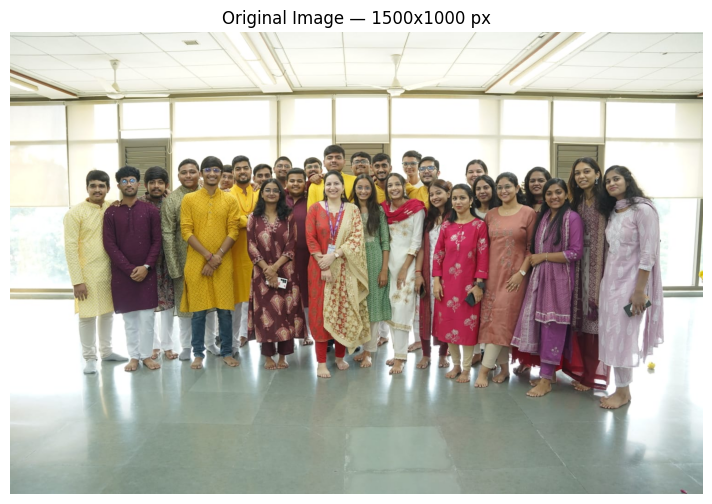

In [3]:
img     = cv2.imread("/content/face_img (1).jpeg")
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

print(f"Image size: {img.shape[1]}x{img.shape[0]} px")

plt.figure(figsize=(10, 6))
plt.imshow(img_rgb)
plt.title(f"Original Image — {img.shape[1]}x{img.shape[0]} px", fontsize=12)
plt.axis('off')
plt.show()

## ⚙️ Step 4 — Load Haar Cascade & Convert to Grayscale

OpenCV ships with pre-trained Haar cascade XML files built-in.
load the frontal face detector

**Why grayscale?**
- Haar features work on **intensity differences** between regions
- Grayscale = 1 channel → 3× faster than processing RGB
- Color adds no useful info for detecting face structure

> 💬 `cv2.data.haarcascades` is the folder path where OpenCV stores its pre-trained XML files.

✅ Haar cascade loaded
Original shape : (1000, 1500, 3)   → (H, W, 3 channels)
Grayscale shape: (1000, 1500)   → (H, W)  — 1 channel only


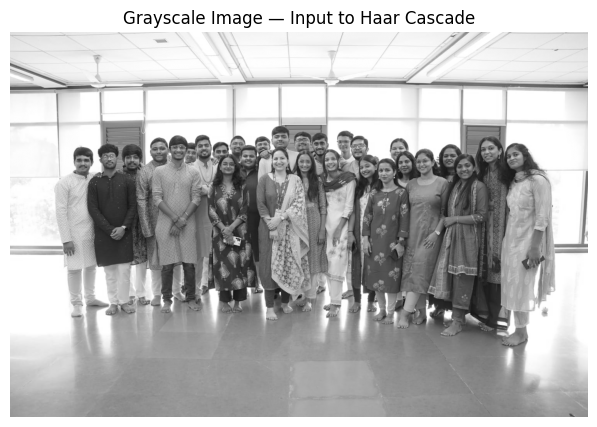

In [4]:
# Load pre-trained Haar cascade — built into OpenCV
face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + 'haarcascade_frontalface_default.xml'
)

# Convert to grayscale — Haar works on intensity, not color
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

print(f"✅ Haar cascade loaded")
print(f"Original shape : {img.shape}   → (H, W, 3 channels)")
print(f"Grayscale shape: {gray.shape}   → (H, W)  — 1 channel only")

plt.figure(figsize=(8, 5))
plt.imshow(gray, cmap='gray')
plt.title('Grayscale Image — Input to Haar Cascade', fontsize=12)
plt.axis('off')
plt.show()

## 🔬 Step 5 — Detect Faces with detectMultiScale()

**`face_cascade.detectMultiScale(image, scaleFactor, minNeighbors, minSize)`**

Internally:
1. Builds an **image pyramid** — resizes image repeatedly by `scaleFactor`
2. At each scale, slides a **64×64 window** across the image
3. At each window position, runs the cascade of weak classifiers
4. Early stages reject non-faces instantly → very fast!
5. If all cascade stages pass → face detected

**`minNeighbors=5`** means a detection is only kept if at least 5 nearby windows also detected a face → removes isolated false positives.

> 💬 Returns array of `(x, y, w, h)` — top-left corner + width + height for each face.

In [5]:
faces = face_cascade.detectMultiScale(
    gray,
    scaleFactor  = 1.1,   # shrink image by 10% each step
    minNeighbors = 5,      # need 5 nearby detections to confirm a face
    minSize      = (40, 40) # ignore detections smaller than 40x40 px
)

print(f"✅ Faces detected: {len(faces)}")
print()
for i, (x, y, w, h) in enumerate(faces):
    print(f"  Face {i+1}: top-left=({x},{y})  size={w}x{h} px")

✅ Faces detected: 26

  Face 1: top-left=(566,10)  size=73x73 px
  Face 2: top-left=(675,251)  size=53x53 px
  Face 3: top-left=(778,271)  size=50x50 px
  Face 4: top-left=(477,276)  size=51x51 px
  Face 5: top-left=(879,276)  size=50x50 px
  Face 6: top-left=(412,280)  size=50x50 px
  Face 7: top-left=(359,283)  size=53x53 px
  Face 8: top-left=(982,283)  size=50x50 px
  Face 9: top-left=(1213,281)  size=57x57 px
  Face 10: top-left=(524,291)  size=50x50 px
  Face 11: top-left=(594,303)  size=49x49 px
  Face 12: top-left=(1116,302)  size=51x51 px
  Face 13: top-left=(1280,299)  size=54x54 px
  Face 14: top-left=(232,301)  size=53x53 px
  Face 15: top-left=(285,300)  size=64x64 px
  Face 16: top-left=(672,308)  size=53x53 px
  Face 17: top-left=(807,311)  size=50x50 px
  Face 18: top-left=(161,312)  size=55x55 px
  Face 19: top-left=(740,317)  size=50x50 px
  Face 20: top-left=(999,318)  size=51x51 px
  Face 21: top-left=(1045,316)  size=52x52 px
  Face 22: top-left=(540,323)  size=52x

## 📐 Step 6 — Draw Bounding Boxes & Count Faces

For each detected face `(x, y, w, h)`:
- `(x, y)` → top-left corner
- `(x+w, y+h)` → bottom-right corner
- Draw a green rectangle + face number label

> 💬 `cv2.putText` draws text on the image. `org` = bottom-left of text, fontScale controls size.

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


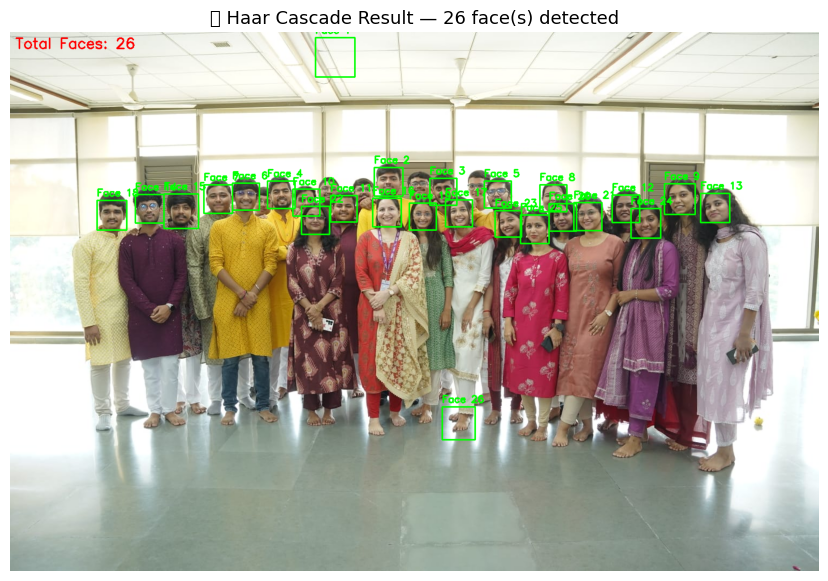

Total faces detected: 26


In [6]:
output = img_rgb.copy()

for i, (x, y, w, h) in enumerate(faces):
    # Draw bounding box
    cv2.rectangle(output, (x, y), (x+w, y+h), (0, 255, 0), 2)

    # Label above the box
    label = f"Face {i+1}"
    cv2.putText(output, label, (x, y - 8),
                cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)

# Count label on image
cv2.putText(output, f"Total Faces: {len(faces)}", (10, 30),
            cv2.FONT_HERSHEY_SIMPLEX, 0.9, (255, 0, 0), 2)

plt.figure(figsize=(12, 7))
plt.imshow(output)
plt.title(f"✅ Haar Cascade Result — {len(faces)} face(s) detected", fontsize=13)
plt.axis('off')
plt.show()

print(f"Total faces detected: {len(faces)}")

## 🔧 Step 7 — Tune Parameters to Reduce False Positives

Sometimes Haar produces **false positives** — non-face regions detected as faces.

We can tune:
- Increase `minNeighbors` → stricter, fewer detections
- Increase `minSize` → ignore tiny false boxes
- Adjust `scaleFactor` → 1.05 = finer search but slower

> 💬 This is a classic **precision vs recall** trade-off:
> - High `minNeighbors` → fewer false positives but may miss real faces
> - Low `minNeighbors` → catches more faces but also more false positives

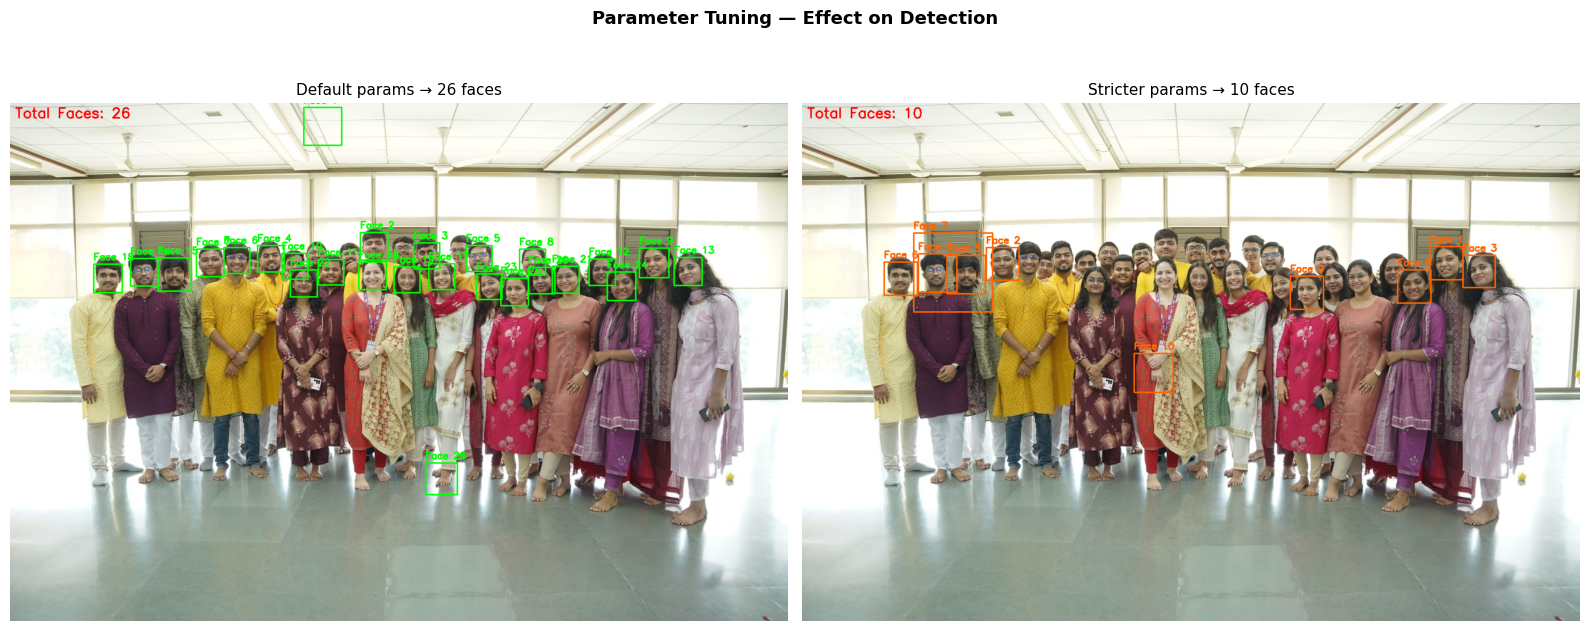

In [7]:
# Stricter detection — fewer false positives
faces_strict = face_cascade.detectMultiScale(
    gray,
    scaleFactor  = 1.05,   # finer scale steps
    minNeighbors = 8,       # stricter — needs more agreement
    minSize      = (60, 60) # ignore anything smaller than 60x60
)

output2 = img_rgb.copy()
for i, (x, y, w, h) in enumerate(faces_strict):
    cv2.rectangle(output2, (x, y), (x+w, y+h), (255, 100, 0), 2)
    cv2.putText(output2, f"Face {i+1}", (x, y-8),
                cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 100, 0), 2)

cv2.putText(output2, f"Total Faces: {len(faces_strict)}", (10, 30),
            cv2.FONT_HERSHEY_SIMPLEX, 0.9, (255, 0, 0), 2)

# Side by side comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
axes[0].imshow(output)
axes[0].set_title(f"Default params → {len(faces)} faces", fontsize=11)
axes[0].axis('off')

axes[1].imshow(output2)
axes[1].set_title(f"Stricter params → {len(faces_strict)} faces", fontsize=11)
axes[1].axis('off')

plt.suptitle("Parameter Tuning — Effect on Detection", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 💾 Step 8 — Save & Download Result

In [8]:
from google.colab import files

output_bgr = cv2.cvtColor(output, cv2.COLOR_RGB2BGR)
cv2.imwrite('face_detection_result.png', output_bgr)
files.download('face_detection_result.png')
print("✅ Result saved and downloaded!")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Result saved and downloaded!
